0. Getting setup



In [1]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12 or int(torch.__version__.split(".")[0]) == 2, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

torch version: 2.11.0+cu128
torchvision version: 0.26.0+cu128



1. Get data
2. Create Datasets and DataLoaders
3. Replicating the ViT paper


In [2]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

[INFO] Couldn't find torchinfo... installing it.
[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4410, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 4410 (delta 5), reused 2 (delta 2), pack-reused 4400 (from 2)
Receiving objects: 100% (4410/4410), 764.18 MiB | 19.72 MiB/s, done.
Resolving deltas: 100% (2661/2661), done.
Updating files: 100% (248/248), done.


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### 1. Get Data


In [4]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] Did not find data/pizza_steak_sushi directory, creating one...
[INFO] Downloading pizza_steak_sushi.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip...
[INFO] Unzipping pizza_steak_sushi.zip data...


PosixPath('data/pizza_steak_sushi')

In [5]:
train_dir = image_path/"train"
test_dir = image_path/"test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

2. Create Datasets and DataLoaders

In [6]:
#i'm gonna transform the image to the right size
IMAGE_SIZE = 224

manual_trasnform = transforms.Compose([
transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
                      transforms.ToTensor(),])
print(f"manual created transform for data:{manual_trasnform}")

manual created transform for data:Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


3. Now we use data loader for the data

In [7]:
#set the batch size
BATCH_SIZE = 32

# MAKE THE DATA INTO DATALODER'S
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
                                                                train_dir= train_dir,
                                                                test_dir= test_dir,
                                                                transform= manual_trasnform,
                                                                batch_size=BATCH_SIZE
                                                                )

In [8]:
train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x799b5d3c57c0>,
 ['pizza', 'steak', 'sushi'])

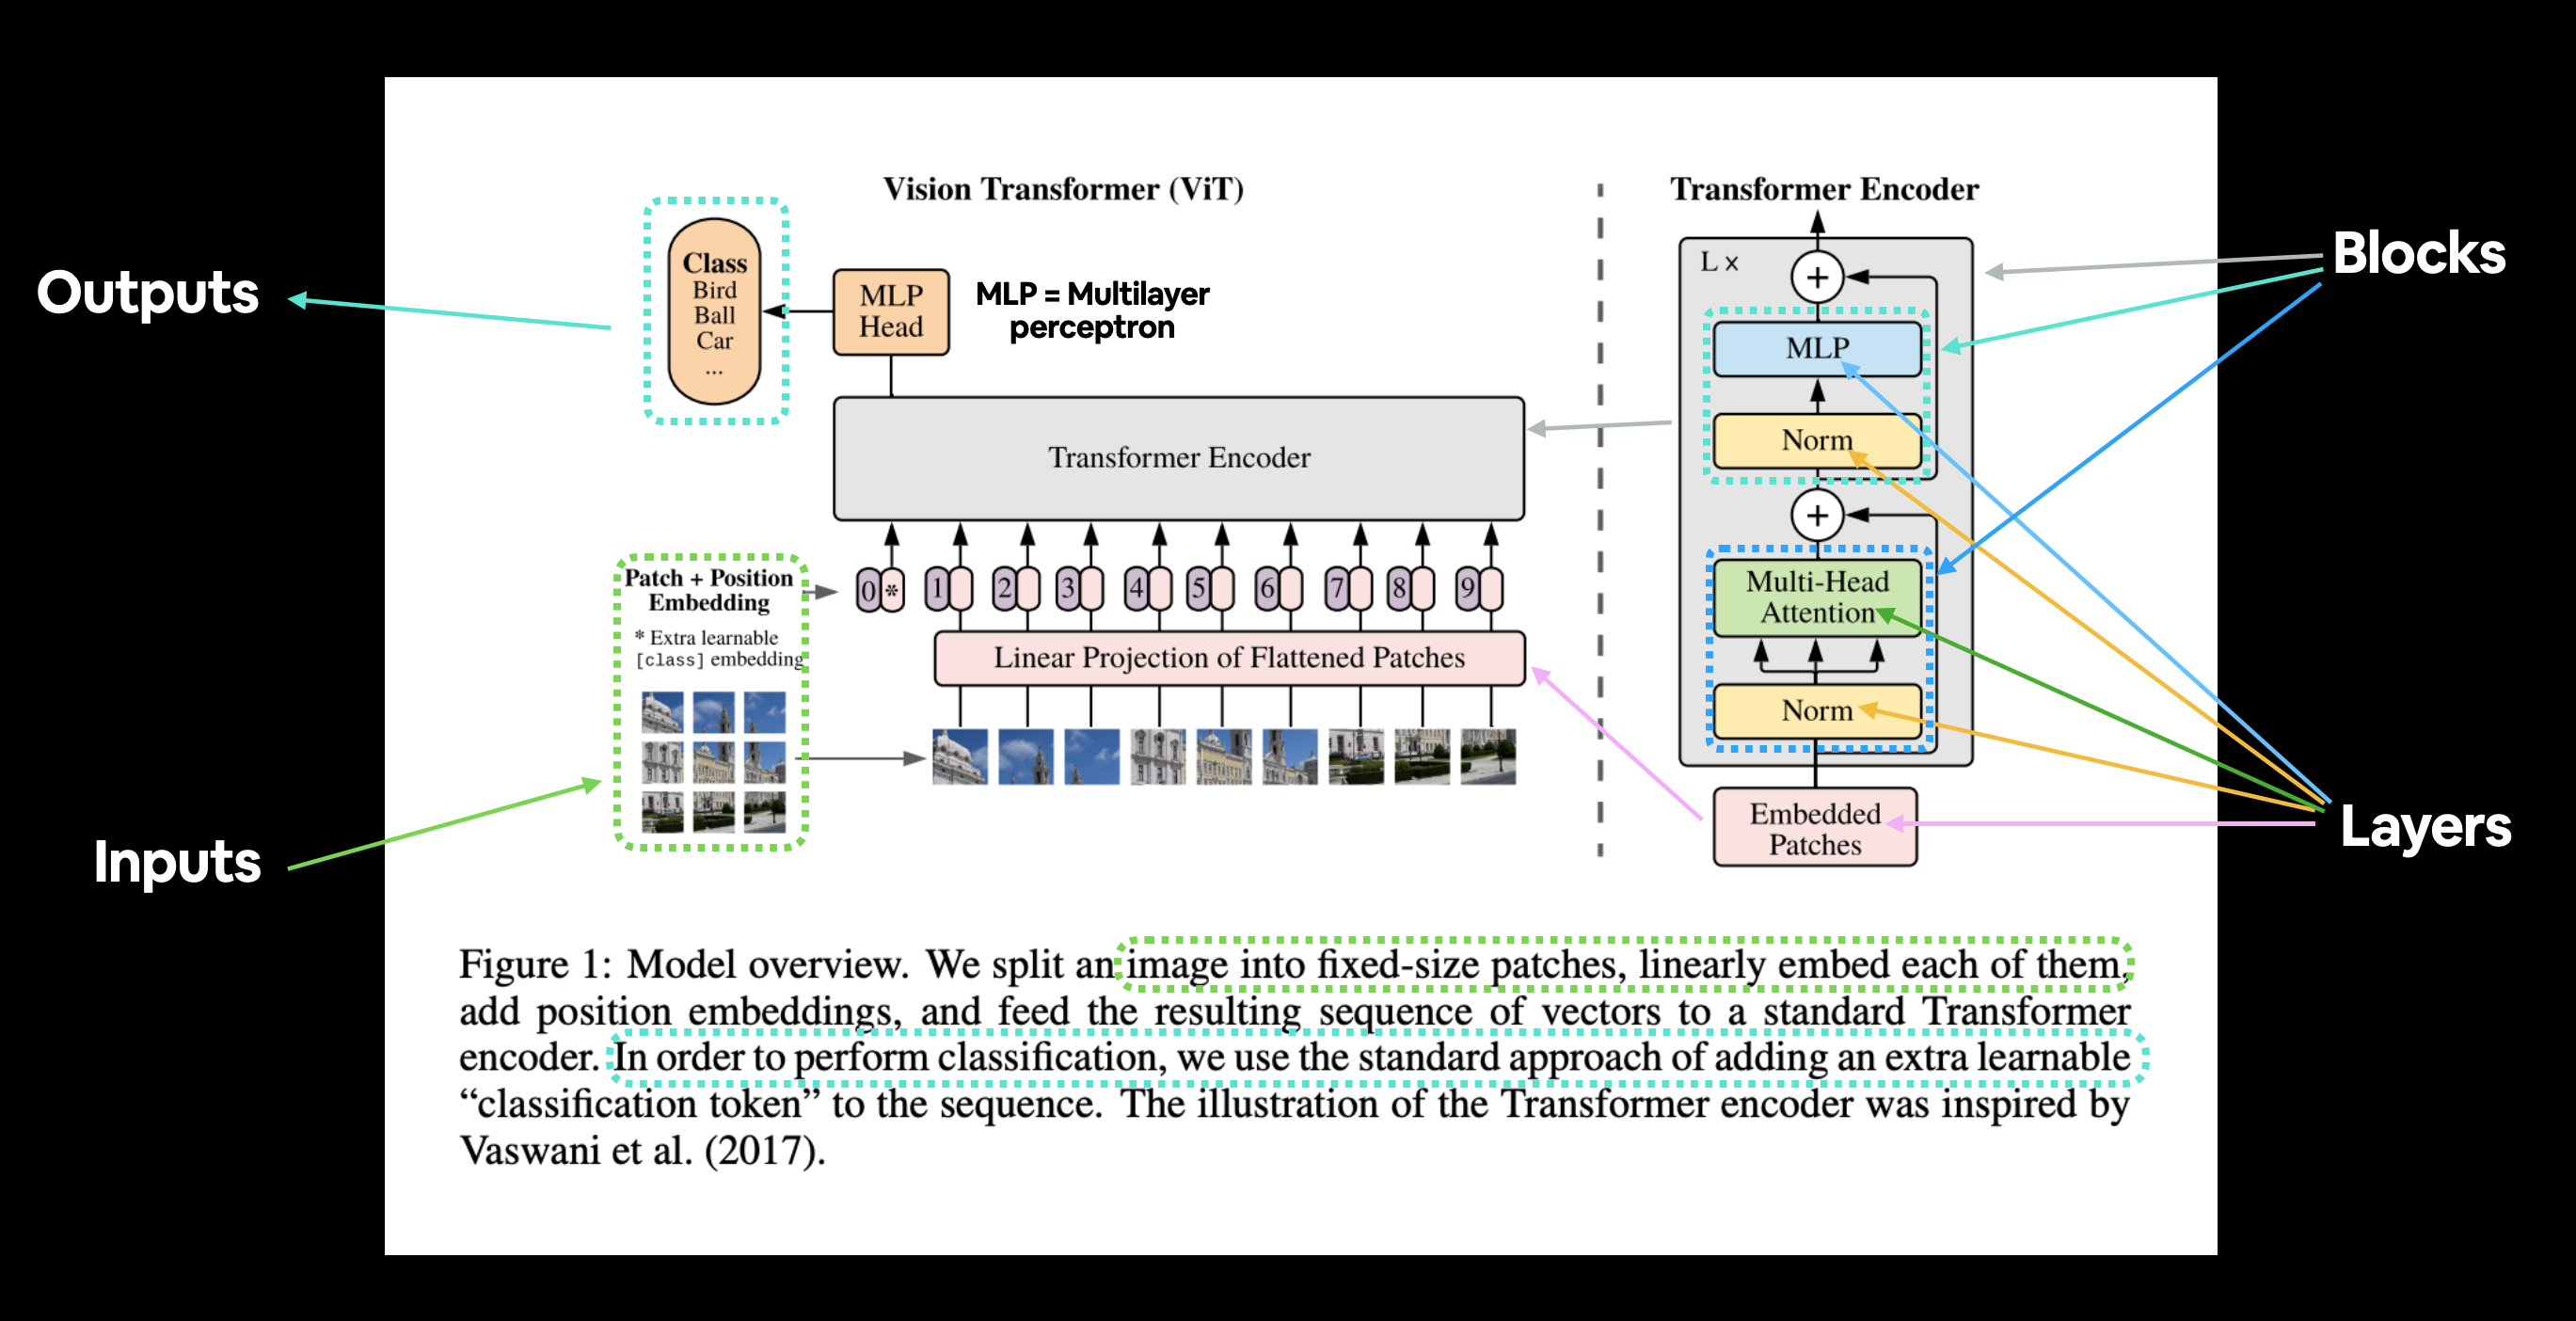

### 4. Start with the *VIT Paper*  model

In [9]:
# 1. Create a class which subclasses nn.Module
class PatchEmbedding(nn.Module):
    """Turns a 2D input image into a 1D sequence learnable embedding vector.

    Args:
        in_channels (int): Number of color channels for the input images. Defaults to 3.
        patch_size (int): Size of patches to convert input image into. Defaults to 16.
        embedding_dim (int): Size of embedding to turn image into. Defaults to 768.
    """
    # 2. Initialize the class with appropriate variables
    def __init__(self,
                 in_channels:int=3,
                 patch_size:int=16,
                 embedding_dim:int=768):
        super().__init__()

        self.patch_size = patch_size # Store patch_size as an instance attribute

        # 3. Create a layer to turn an image into patches
        self.patcher = nn.Conv2d(in_channels=in_channels,
                                 out_channels=embedding_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size,
                                 padding=0)

        # 4. Create a layer to flatten the patch feature maps into a single dimension
        self.flatten = nn.Flatten(start_dim=2, # only flatten the feature map dimensions into a single vector
                                  end_dim=3)

    # 5. Define the forward method
    def forward(self, x):
        # Create assertion to check that inputs are the correct shape
        image_resolution = x.shape[-1]
        assert image_resolution % self.patch_size == 0, f"Input image size must be divisible by patch size, image shape: {image_resolution}, patch size: {self.patch_size}"

        # Perform the forward pass
        x_patched = self.patcher(x)
        x_flattened = self.flatten(x_patched)
        # 6. Make sure the output shape has the right order
        return x_flattened.permute(0, 2, 1) # adjust so the embedding is on the final dimension [batch_size, P^2•C, N] -> [batch_size, N, P^2•C]

In [10]:
# 1. Create a class that inherits from nn.Module
class MultiheadSelfAttentionBlock(nn.Module):
    """Creates a multi-head self-attention block ("MSA block" for short).
    """
    # 2. Initialize the class with hyperparameters from Table 1
    def __init__(self,
                 embedding_dim:int=768, # Hidden size D from Table 1 for ViT-Base
                 num_heads:int=12, # Heads from Table 1 for ViT-Base
                 attn_dropout:float=0): # doesn't look like the paper uses any dropout in MSABlocks
        super().__init__()

        # 3. Create the Norm layer (LN)
        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        # 4. Create the Multi-Head Attention (MSA) layer
        self.multihead_attn = nn.MultiheadAttention(embed_dim=embedding_dim,
                                                    num_heads=num_heads,
                                                    dropout=attn_dropout,
                                                    batch_first=True) # does our batch dimension come first?

    # 5. Create a forward() method to pass the data through the layers
    def forward(self, x):
        x = self.layer_norm(x)
        attn_output, _ = self.multihead_attn(query=x, # query embeddings
                                             key=x, # key embeddings
                                             value=x, # value embeddings
                                             need_weights=False) # do we need the weights or just the layer outputs?
        return attn_output


<img src="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/images/08-vit-paper-equation-3-annotated.png" alt="mapping equation 3 from the ViT paper to the ViT architecture diagram in figure 1" width=900/>

In [11]:
# 1. Create a class that inherits from nn.Module
class MLPBlock(nn.Module):
    """Creates a layer normalized multilayer perceptron block ("MLP block" for short)."""
    # 2. Initialize the class with hyperparameters from Table 1 and Table 3
    def __init__(self,
                 embedding_dim:int=768, # Hidden Size D from Table 1 for ViT-Base
                 mlp_size:int=3072, # MLP size from Table 1 for ViT-Base
                 dropout:float=0.1): # Dropout from Table 3 for ViT-Base
        super().__init__()

        # 3. Create the Norm layer (LN)
        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        # 4. Create the Multilayer perceptron (MLP) layer(s)
        self.mlp = nn.Sequential(
            nn.Linear(in_features=embedding_dim,
                      out_features=mlp_size),
            nn.GELU(), # "The MLP contains two layers with a GELU non-linearity (section 3.1)."
            nn.Dropout(p=dropout),
            nn.Linear(in_features=mlp_size, # needs to take same in_features as out_features of layer above
                      out_features=embedding_dim), # take back to embedding_dim
            nn.Dropout(p=dropout) # "Dropout, when used, is applied after every dense layer.."
        )

    # 5. Create a forward() method to pass the data through the layers
    def forward(self, x):
        x = self.layer_norm(x)
        x = self.mlp(x)
        return x

In [12]:
# 1. Create a class that inherits from nn.Module
class TransformerEncoderBlock(nn.Module):
    """Creates a Transformer Encoder block."""
    # 2. Initialize the class with hyperparameters from Table 1 and Table 3
    def __init__(self,
                 embedding_dim:int=768, # Hidden size D from Table 1 for ViT-Base
                 num_heads:int=12, # Heads from Table 1 for ViT-Base
                 mlp_size:int=3072, # MLP size from Table 1 for ViT-Base
                 mlp_dropout:float=0.1, # Amount of dropout for dense layers from Table 3 for ViT-Base
                 attn_dropout:float=0): # Amount of dropout for attention layers
        super().__init__()

        # 3. Create MSA block (equation 2)
        self.msa_block = MultiheadSelfAttentionBlock(embedding_dim=embedding_dim,
                                                     num_heads=num_heads,
                                                     attn_dropout=attn_dropout)

        # 4. Create MLP block (equation 3)
        self.mlp_block =  MLPBlock(embedding_dim=embedding_dim,
                                   mlp_size=mlp_size,
                                   dropout=mlp_dropout)

    # 5. Create a forward() method
    def forward(self, x):

        # 6. Create residual connection for MSA block (add the input to the output)
        x =  self.msa_block(x) + x

        # 7. Create residual connection for MLP block (add the input to the output)
        x = self.mlp_block(x) + x

        return x

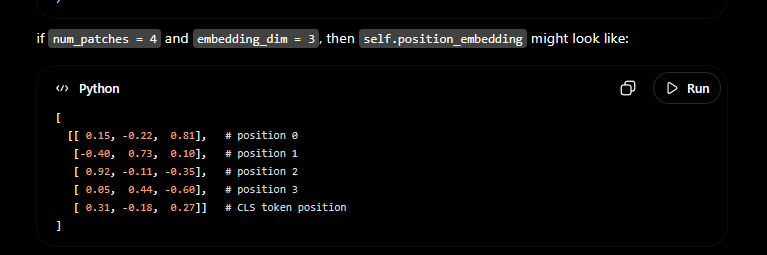


1. Create a class called `ViT` that inherits from `torch.nn.Module`.
2. Initialize the class with hyperparameters from Table 1 and Table 3 of the ViT paper for the ViT-Base model.
3. Make sure the image size is divisible by the patch size (the image should be split into even patches).
4. Calculate the number of patches using the formula $N=H W / P^{2}$, where $H$ is the image height, $W$ is the image width and $P$ is the patch size.
5. Create a learnable class embedding token (equation 1) as done above in section 4.6.
6. Create a learnable position embedding vector (equation 1) as done above in section 4.7.
7. Setup the embedding dropout layer as discussed in Appendix B.1 of the ViT paper.
8. Create the patch embedding layer using the `PatchEmbedding` class as above in section 4.5.
9. Create a series of Transformer Encoder blocks by passing a list of `TransformerEncoderBlock`s created in section 7.1 to `torch.nn.Sequential()` (equations 2 & 3).
10. Create the MLP head (also called classifier head or equation 4) by passing a `torch.nn.LayerNorm()` (LN) layer and a `torch.nn.Linear(out_features=num_classes)` layer (where `num_classes` is the target number of classes) linear layer to `torch.nn.Sequential()`.
11. Create a `forward()` method that accepts an input.
12. Get the batch size of the input (the first dimension of the shape).
13. Create the patching embedding using the layer created in step 8 (equation 1).
14. Create the class token embedding using the layer created in step 5 and expand it across the number of batches found in step 11 using [`torch.Tensor.expand()`](https://pytorch.org/docs/stable/generated/torch.Tensor.expand.html) (equation 1).
15. Concatenate the class token embedding created in step 13 to the first dimension of the patch embedding created in step 12 using [`torch.cat()`](https://pytorch.org/docs/stable/generated/torch.cat.html) (equation 1).
16. Add the position embedding created in step 6 to the patch and class token embedding created in step 14 (equation 1).
17. Pass the patch and position embedding through the dropout layer created in step 7.
18. Pass the patch and position embedding from step 16 through the stack of Transformer Encoder layers created in step 9 (equations 2 & 3).
19. Pass index 0 of the output of the stack of Transformer Encoder layers from step 17 through the classifier head created in step 10 (equation 4).

In [13]:
class VITEncoder(nn.Module):
  def __init__(
      self,
      num_transformer_layers: int= 12,
      num_heads: int = 12,
      dropout: float=0.1,
      num_classes: int=3,
      patch_size: int=16,
      embedding_dropout: float=0.1,
      in_channels: int = 3,
      image_size: int = 224,
      embedding_dim: int = 768,
      mlp_size: int = 3072,
      mlp_dropout: float = 0.1
  ):
    super().__init__()
    #3 make sure that the patches don't mismatch with the image
    assert image_size % patch_size == 0 , "image must be divisible by patch size"
    #4 number of patches
    self.num_patches = (image_size * image_size // patch_size ** 2)
    #5 learnable class embading
    self.class_embedding = nn.Parameter(torch.randn(1,1,embedding_dim), requires_grad=True)
    #6 now we prepare the place of the position embedding
    self.position_embedding = nn.Parameter(torch.randn(1,1+self.num_patches,embedding_dim), requires_grad=True)
    #7 we use dropout for the embedding
    self.embedding_dropout = nn.Dropout(p=embedding_dropout)
    #8 class embadding that we prepared with CNN layer
    self.patch_embedding =  PatchEmbedding(in_channels=in_channels,
                                                  patch_size=patch_size,
                                                  embedding_dim=embedding_dim)

    #9 prapare the encoder block with the 12 layers using sequential
    self.transformer_encoder = nn.Sequential(*[TransformerEncoderBlock(embedding_dim=embedding_dim,
                                                                      mlp_size=mlp_size,
                                                                      num_heads=num_heads,
                                                                      mlp_dropout=mlp_dropout) for _ in range(num_transformer_layers)])
    self.classifier_head = nn.Sequential(
        nn.LayerNorm(embedding_dim),
        nn.Linear(embedding_dim, num_classes)
    )

  def forward(self, x):
    #10 Get batch size
    batch_size = x.shape[0]
    #11 create the token
    token = self.class_embedding.expand(batch_size,-1,-1)

    # 12. Create patch embedding (equation 1)
    x = self.patch_embedding(x)

    #13 concatenate the token with the patch embedding
    x = torch.cat((token,x), dim=1 )

    #14 ADD THE position embedding
    x = self.position_embedding + x
    # 15 add the embedding dropout
    x = self.embedding_dropout(x)
    # 16 Pass patch, position and class embedding through transformer encoder layers (equations 2 & 3)
    x = self.transformer_encoder(x)
    # 17 now after the block of encoder we pass every think to the mlp
    x = self.classifier_head(x[:,0])
    return x


In [14]:

# Create a random tensor with same shape as a single image
random_image_tensor = torch.randn(1, 3, 224, 224) # (batch_size, color_channels, height, width)

# Create an instance of ViT with the number of classes we're working with (pizza, steak, sushi)
vit = VITEncoder(num_classes=len(class_names))

# Pass the random image tensor to our ViT instance
vit(random_image_tensor)

tensor([[ 0.0167, -0.5553,  0.4621]], grad_fn=<AddmmBackward0>)

In [18]:
from torchinfo import summary

# # Print a summary of our custom ViT model using torchinfo (uncomment for actual output)
#summary(model=vit,
#       input_size=(32, 3, 224, 224), # (batch_size, color_channels, height, width)
#         # col_names=["input_size"], # uncomment for smaller output
#         col_names=["input_size", "output_size", "num_params", "trainable"],
#         col_width=20,
#         row_settings=["var_names"]
# )

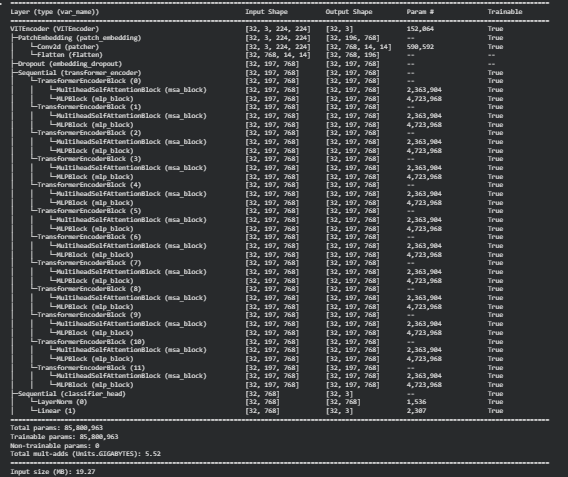

In [16]:
  #for param in vit.parameters():# if u need to change all the VITEncoder parameters to not trainable parameters use it
    #param.requires_grad = False

In [25]:
from going_modular.going_modular import engine

# Create optimizer and loss function
optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

# Train the classifier head of the pretrained ViT feature extractor model
set_seeds()
vit_results = engine.train(model=vit,
                                      train_dataloader=train_dataloader,
                                      test_dataloader=test_dataloader,
                                      optimizer=optimizer,
                                      loss_fn=loss_fn,
                                      epochs=10,
                                      device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0877 | train_acc: 0.4648 | test_loss: 1.2545 | test_acc: 0.3438
Epoch: 2 | train_loss: 1.0102 | train_acc: 0.5820 | test_loss: 1.1407 | test_acc: 0.3333
Epoch: 3 | train_loss: 0.9712 | train_acc: 0.5781 | test_loss: 1.1031 | test_acc: 0.3229
Epoch: 4 | train_loss: 1.1105 | train_acc: 0.4570 | test_loss: 1.0964 | test_acc: 0.3333
Epoch: 5 | train_loss: 1.1181 | train_acc: 0.3672 | test_loss: 1.1211 | test_acc: 0.3816
Epoch: 6 | train_loss: 1.1599 | train_acc: 0.3906 | test_loss: 1.0731 | test_acc: 0.3333
Epoch: 7 | train_loss: 0.9892 | train_acc: 0.5781 | test_loss: 1.1320 | test_acc: 0.3428
Epoch: 8 | train_loss: 1.0686 | train_acc: 0.4414 | test_loss: 1.1731 | test_acc: 0.3523
Epoch: 9 | train_loss: 1.0156 | train_acc: 0.4414 | test_loss: 1.1041 | test_acc: 0.3333
Epoch: 10 | train_loss: 1.0285 | train_acc: 0.4180 | test_loss: 1.0334 | test_acc: 0.5237


In [45]:
# 1. Get pretrained weights for ViT-Base
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT # requires torchvision >= 0.13, "DEFAULT" means best available

# 2. Setup a ViT model instance with pretrained weights
pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_vit_weights).to(device)

#3. now we frozen all the parameters
for param in pretrained_vit.parameters():
  param.requires_grad = False

#4 at this point we put make the head trainable
pretrained_vit.heads= nn.Linear(in_features=768, out_features= len(class_names), bias=True).to(device)


In [46]:
pretrained_vit.heads

Linear(in_features=768, out_features=3, bias=True)

OK now let's train the pratrained vit

In [50]:
from going_modular.going_modular import engine

# Create optimizer and loss function
optimizer = torch.optim.Adam(params=pretrained_vit.parameters(),
                             lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

# Train the classifier head of the pretrained ViT feature extractor model
set_seeds()
pretrained_vit_results = engine.train(model=pretrained_vit,
                                      train_dataloader=train_dataloader,
                                      test_dataloader=test_dataloader,
                                      optimizer=optimizer,
                                      loss_fn=loss_fn,
                                      epochs=10,
                                      device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.7877 | train_acc: 0.6250 | test_loss: 0.6720 | test_acc: 0.7547
Epoch: 2 | train_loss: 0.4637 | train_acc: 0.8906 | test_loss: 0.4235 | test_acc: 0.8977
Epoch: 3 | train_loss: 0.3028 | train_acc: 0.9336 | test_loss: 0.3258 | test_acc: 0.8977
Epoch: 4 | train_loss: 0.2403 | train_acc: 0.9492 | test_loss: 0.2838 | test_acc: 0.8977
Epoch: 5 | train_loss: 0.1937 | train_acc: 0.9492 | test_loss: 0.2683 | test_acc: 0.8977
Epoch: 6 | train_loss: 0.1771 | train_acc: 0.9609 | test_loss: 0.2429 | test_acc: 0.8977
Epoch: 7 | train_loss: 0.1580 | train_acc: 0.9688 | test_loss: 0.2419 | test_acc: 0.8977
Epoch: 8 | train_loss: 0.1366 | train_acc: 0.9727 | test_loss: 0.2405 | test_acc: 0.9081
Epoch: 9 | train_loss: 0.1849 | train_acc: 0.9766 | test_loss: 0.2178 | test_acc: 0.9176
Epoch: 10 | train_loss: 0.1301 | train_acc: 0.9609 | test_loss: 0.2060 | test_acc: 0.9176


data/pizza_steak_sushi/04-pizza-dad.jpeg already exists, skipping download.


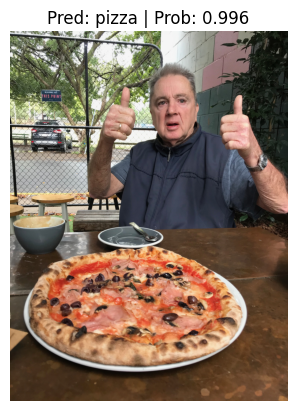

In [55]:
import requests

# Import function to make predictions on images and plot them
from going_modular.going_modular.predictions import pred_and_plot_image

# Setup custom image path
custom_image_path = image_path / "04-pizza-dad.jpeg"

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # When downloading from GitHub, need to use the "raw" file link
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

# Predict on custom image
pred_and_plot_image(model=pretrained_vit,
                    image_path=custom_image_path,
                    class_names=class_names)


| **Model** | **Model size (MB)** | **Test loss** | **Test accuracy** |
| ----- | ----- | ----- | ------ |
| replicate VIT | 327 | ~1.0334  | ~0.5237 |
| pretrained ViT^ | 327 | ~0.2060 | ~0.9176 |

THIS HAPPENED because our model trained on a part of a dataset around 250 image in our dataset not like the preatrained model was trained on the 14 million images like they mentioned in the paper, we don't have enough compute power to train the model